#### Placebo / randomization-inference null for the FRAGMENTATION INDEX — frequency-pruned sequences
#### By: Peyman Shahidi (robustness build)
#### Created: 2026-06-25

**New exercise (the paper never ran a placebo for the fragmentation index).** The fragmentation index is
*order-dependent* — it counts switches between AI-chains and manual tasks along the occupation's task
sequence. So the position-reshuffle null is exactly the right test: *is the observed relationship between the
fragmentation index and the AI-execution share stronger than under random task ordering?*

**Design (identical to the neighbor placebo).** One position shuffle per occupation per draw (same mechanic and
seeds as the main analysis, `random_state = 42 + i`), reused across every cut. For each frequency cut we apply
the filter to the shuffled sequence, **recompute the fragmentation index on the reshuffled order**, and re-run
the paper's regression `ai_fraction ~ fragmentation_index + ai_exposure (+ SOC FE)`. The outcome (AI-execution
share) and the exposure control are order-independent, so the null isolates the effect of *ordering* on the FI
coefficient.

**Main specs:** the two exposure-based definitions **FI v3** (E1) and **FI v4** (E1|E2, preferred) ×
{No FE, Major-group FE, Minor-group FE}. **All three variables (AI-execution share, fragmentation index, AI
exposure) are z-scored within each cut** (standardized betas, as in the main spec), clustered on the detailed
occupation code. Observed marker shown with its 90% CI
(coef ± 1.645·SE), in the main-results palette.

**Full run: `N_RESHUFFLES = 1000`** (timing trial measured ~0.82 s/draw → ~14 min). Null draws saved
incrementally.

In [1]:
import os, time
import numpy as np, pandas as pd
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')
pd.set_option('display.width', 200)

In [2]:
# ====================== PARAMETERS ======================
N_RESHUFFLES = 1000          # full run (timing trial measured ~0.82s/draw -> ~14 min)
SHUFFLE_SEED_BASE = 42       # same base seed as the main-analysis placebo

onet_occupation_code_var = 'Detailed_Occupation_Code'
onet_occupation_title_var = 'Detailed_Occupation_Title'
ai_exposure_var = 'human_E1_fraction'
MIN_TASKS_PER_OCC = 3
FI_DEFS = [3, 4]
FI_DEF_TITLE = {3: 'FI v3 (exposure E1)', 4: 'FI v4 (exposure E1|E2)'}
FE_SPECS = ['none', 'Major', 'Minor']
FE_LABEL = {'none': 'No FE', 'Major': 'Major FE', 'Minor': 'Minor FE'}

FT_DAILY        = ['FT_Daily', 'FT_Several times daily', 'FT_Hourly or more']        # FT 5-7
FT_SEVERALDAILY = ['FT_Several times daily', 'FT_Hourly or more']                     # FT 6-7
FT_HOURLY       = ['FT_Hourly or more']                                               # FT 7
FAMILIES = [('Daily+', 'daily', FT_DAILY), ('SeveralDaily+', 'sevdaily', FT_SEVERALDAILY), ('Hourly+', 'hourly', FT_HOURLY)]
SWEEP_THRESHOLDS = [20, 35, 50, 65]
PLACEBO_CUTS = [('All tasks', 'all', None, None)]
for lab, tag, cols in FAMILIES:
    for t in SWEEP_THRESHOLDS:
        PLACEBO_CUTS.append((f"{lab} >={t}%", f"{tag}{t}", cols, t))

In [3]:
main_folder_path = ".."
input_data_path = f"{main_folder_path}/data"
input_file_path = f"{input_data_path}/computed_objects/ONET_Eloundou_Anthropic_GPT/ONET_Eloundou_Anthropic_GPT.csv"
output_data_path = f"{input_data_path}/computed_objects/fragmentationIndex_weeklyTasks"
output_plot_path = f"{main_folder_path}/writeup/plots/fragmentationIndex_weeklyTasks/placebo"
for p in [output_data_path, output_plot_path]: os.makedirs(p, exist_ok=True)

ONET = pd.read_csv(f"{input_data_path}/computed_objects/ONET_cleaned_tasks.csv")
SOC_mappings = ONET[['O*NET-SOC Code', 'Occupation Title', 'Major_Group_Code', 'Major_Group_Title',
                     'Minor_Group_Code', 'Minor_Group_Title', 'Broad_Occupation_Code', 'Broad_Occupation_Title',
                     'Detailed_Occupation_Code', 'Detailed_Occupation_Title']].copy()
SOC_mappings = SOC_mappings.drop_duplicates(subset=['O*NET-SOC Code', onet_occupation_code_var])

## FI helper functions (identical to the baseline; `construct_fragmentation_index` sorts by Task Position so the reshuffled order is respected)

In [4]:
def create_occupation_analysis(df):
    rows = []
    for (soc, title), g in df.groupby(['O*NET-SOC Code', 'Occupation Title']):
        n = len(g)
        rows.append({'O*NET-SOC Code': soc, 'Occupation Title': title, 'num_tasks': g['Task ID'].nunique(),
                     'ai_fraction': (g['label'].isin(['Augmentation', 'Automation'])).sum() / n,
                     'human_E1_fraction': (g['human_labels'] == 'E1').sum() / n})
    return pd.DataFrame(rows)

def construct_fragmentation_index(df, definition):
    fi = df.sort_values(['O*NET-SOC Code', 'Task Position']).copy()   # respect (possibly reshuffled) order
    if definition == 3:
        fi['is_ai'] = fi['human_labels'].isin(['E1']).astype(int)
    elif definition == 4:
        fi['is_ai'] = fi['human_labels'].isin(['E1', 'E2']).astype(int)
    fi['next_is_ai'] = fi.groupby(['O*NET-SOC Code', 'Occupation Title'])['is_ai'].shift(-1).fillna(0).astype(int)
    fi['num_switches'] = 1
    fi.loc[(fi['is_ai'] == 1) & (fi['next_is_ai'] == 1), 'num_switches'] = 0
    return (fi.groupby(['O*NET-SOC Code', 'Occupation Title'])['num_switches'].mean()
              .reset_index().rename(columns={'num_switches': 'fragmentation_index'}))

def aggregate(occ):
    occ = occ.merge(SOC_mappings, on=['O*NET-SOC Code', 'Occupation Title'], how='left')
    agg = occ.groupby([onet_occupation_code_var, onet_occupation_title_var]).agg(
        {'fragmentation_index': 'mean', ai_exposure_var: 'mean', 'ai_fraction': 'mean'}).reset_index()
    agg = agg.merge(SOC_mappings, on=onet_occupation_code_var, how='left', suffixes=('', '_drop'))
    agg = agg.loc[:, ~agg.columns.str.endswith('_drop')]
    return agg

def coefs_for_cut(d_cut, occ_base):
    '''Standardized (z-scored) FI coefficient + clustered SE + p, for FI v3,v4 x {none,Major,Minor}.
    All three regression variables are z-scored within the cut (as in the main spec). FI recomputed per def
    on d_cut's (current) Task-Position order; occ_base holds the order-independent ai_fraction / exposure.'''
    out = {}
    for definition in FI_DEFS:
        fi = construct_fragmentation_index(d_cut, definition)
        agg = aggregate(occ_base.merge(fi, on=['O*NET-SOC Code', 'Occupation Title'], how='left'))
        agg = agg.rename(columns={ai_exposure_var: 'ai_exposure'})
        for c in ('Major_Group_Code', 'Minor_Group_Code', onet_occupation_code_var):
            agg[c] = agg[c].astype('object')
        for _z in ['ai_fraction', 'ai_exposure', 'fragmentation_index']:   # z-score all three (interpretable betas)
            _s = agg[_z]; _sd = _s.std()
            agg[_z] = (_s - _s.mean()) / _sd if (_sd and not np.isnan(_sd)) else np.nan
        clu = dict(cov_type='cluster', cov_kwds={'groups': agg[onet_occupation_code_var],
                                                 'use_correction': True, 'df_correction': True})
        for fe in FE_SPECS:
            fe_term = '' if fe == 'none' else ' + C(Major_Group_Code)' if fe == 'Major' else ' + C(Minor_Group_Code)'
            try:
                if len(agg) < 10 or agg['fragmentation_index'].nunique() < 2:
                    raise ValueError('too small')
                m = smf.ols(f'ai_fraction ~ fragmentation_index + ai_exposure{fe_term}', data=agg).fit(**clu)
                out[(definition, fe)] = (m.params['fragmentation_index'], m.bse['fragmentation_index'], m.pvalues['fragmentation_index'])
            except Exception:
                out[(definition, fe)] = (np.nan, np.nan, np.nan)
    return out

## Build the task pool and pre-compute each cut's task set + order-independent occupation stats

In [5]:
POOL = pd.read_csv(input_file_path)[['O*NET-SOC Code', 'Occupation Title', 'Task ID', 'Task Position',
        'label', 'human_labels', 'gpt4_exposure', 'Detailed_Occupation_Code', 'Major_Group_Code',
        'Minor_Group_Code', 'FT_Daily', 'FT_Several times daily', 'FT_Hourly or more']].copy()
POOL['Task Position'] = pd.to_numeric(POOL['Task Position'], errors='coerce')

# --- neighbor sample's occupation set per cut (so fragmentation is estimated on the SAME occupations as the neighbor analysis) ---
_dwa_map = pd.read_csv(f"{input_data_path}/computed_objects/similar_dwa_tasks/dwa_task_mapping.csv")
_uniq = _dwa_map.groupby('Task ID')['DWA ID'].nunique().reset_index(name='_n')
_single_dwa = _uniq[_uniq['_n'] == 1]['Task ID'].tolist()
_ALLFT = ['FT_Yearly or less', 'FT_More than yearly', 'FT_More than monthly', 'FT_More than weekly',
          'FT_Daily', 'FT_Several times daily', 'FT_Hourly or more']
_npool = pd.read_csv(input_file_path)[['O*NET-SOC Code', 'Occupation Title', 'Task ID', 'Task Title', 'Task Position', 'label'] + _ALLFT].copy()
_npool['is_ai'] = _npool['label'].isin(['Augmentation', 'Automation']).astype(int)
_npool['Task Position'] = pd.to_numeric(_npool['Task Position'], errors='coerce')
_npool = _npool.merge(_dwa_map, on=['Task ID', 'Task Title', 'O*NET-SOC Code', 'Occupation Title'], how='left')
_npool = _npool[_npool['Task ID'].isin(_single_dwa)].drop_duplicates(subset=['O*NET-SOC Code', 'Task ID'])
_npool = _npool[~_npool['DWA ID'].isna()]
_oc = _npool.groupby('DWA ID')['O*NET-SOC Code'].nunique(); _npool = _npool[_npool['DWA ID'].isin(_oc[_oc > 1].index)]

def neighbor_occ_set(family_cols, threshold):
    """Occupations in the neighbor regression sample for this cut: O*NET-SOC codes that retain a
    fully-neighbored task (t-2..t+2 all defined) after the DWA filters + frequency filter."""
    d = _npool if family_cols is None else _npool[_npool[family_cols].sum(axis=1) >= threshold]
    d = d.sort_values(['O*NET-SOC Code', 'Task Position'])
    g = d.groupby('O*NET-SOC Code')['is_ai']
    fl = pd.concat([g.shift(1), g.shift(2), g.shift(-1), g.shift(-2)], axis=1)
    return set(d[fl.notna().all(axis=1)]['O*NET-SOC Code'])

def filter_cut(pool, cols, thr):
    d = pool if cols is None else pool[pool[cols].sum(axis=1) >= thr]
    # Restrict to the neighbor sample's occupations (comparable samples).
    return d[d['O*NET-SOC Code'].isin(neighbor_occ_set(cols, thr))].reset_index(drop=True)

# order-independent per-cut occupation stats (ai_fraction, exposure) + valid occupation set
CUT_INFO = {}
for label, tag, cols, thr in PLACEBO_CUTS:
    d = filter_cut(POOL, cols, thr)
    CUT_INFO[tag] = {'cols': cols, 'thr': thr, 'valid': set(d['O*NET-SOC Code'].unique()),
                     'occ_base': create_occupation_analysis(d)}
print("cut sizes (occupations):", {tag: len(CUT_INFO[tag]['occ_base']) for tag in CUT_INFO})

cut sizes (occupations): {'all': 865, 'daily20': 792, 'daily35': 662, 'daily50': 523, 'daily65': 384, 'sevdaily20': 493, 'sevdaily35': 315, 'sevdaily50': 178, 'sevdaily65': 76, 'hourly20': 282, 'hourly35': 123, 'hourly50': 49, 'hourly65': 6}


## Observed FI coefficients (no shuffle) + sanity check vs the sweep

In [6]:
observed = {}   # observed[tag][(def, fe)] = (coef, se, pval)
for label, tag, cols, thr in PLACEBO_CUTS:
    d = filter_cut(POOL, cols, thr)
    observed[tag] = coefs_for_cut(d, CUT_INFO[tag]['occ_base'])
obs_rows = [{'cut_tag': tag, 'cut': lbl, 'FI_def': f'v{dfn}', 'FE': fe,
             'coef': observed[tag][(dfn, fe)][0], 'se': observed[tag][(dfn, fe)][1], 'pval': observed[tag][(dfn, fe)][2]}
            for (lbl, tag, cols, thr) in PLACEBO_CUTS for dfn in FI_DEFS for fe in FE_SPECS]
pd.DataFrame(obs_rows).to_csv(f"{output_data_path}/frag_placebo_observed.csv", index=False)
# sanity vs the sweep: All tasks FI v4 no-FE coef ~ -0.23 ; Daily+>=50% ~ -0.23
print("sanity — FI v4 no-FE observed coef:  All tasks =", round(observed['all'][(4, 'none')][0], 3),
      " | Daily+ >=50% =", round(observed['daily50'][(4, 'none')][0], 3))

sanity — FI v4 no-FE observed coef:  All tasks = -0.369  | Daily+ >=50% = -0.194


## Reshuffle loop (TIMING TRIAL). One shuffle per draw, reused across cuts.

In [7]:
def shuffle_pool(pool, seed):
    d = pool.copy()
    d['Task Position'] = d.groupby('O*NET-SOC Code')['Task Position'].transform(
        lambda x: x.sample(frac=1, random_state=seed).values)
    return d

null_rows = []
t0 = time.time()
PRINT_EVERY = max(1, N_RESHUFFLES // 40); SAVE_EVERY = max(1, N_RESHUFFLES // 10)
for i in range(N_RESHUFFLES):
    sp = shuffle_pool(POOL, SHUFFLE_SEED_BASE + i)
    for label, tag, cols, thr in PLACEBO_CUTS:
        info = CUT_INFO[tag]
        d = sp if cols is None else sp[sp[cols].sum(axis=1) >= thr]
        d = d[d['O*NET-SOC Code'].isin(info['valid'])]
        res = coefs_for_cut(d, info['occ_base'])
        for dfn in FI_DEFS:
            for fe in FE_SPECS:
                null_rows.append({'cut_tag': tag, 'cut': label, 'FI_def': f'v{dfn}', 'FE': fe,
                                  'draw': i, 'coef': res[(dfn, fe)][0]})
    if (i + 1) % PRINT_EVERY == 0 or i == 0:
        el = time.time() - t0
        print(f"  draw {i+1}/{N_RESHUFFLES} | {el/60:4.1f}m | {el/(i+1):4.2f}s/draw", flush=True)
    if (i + 1) % SAVE_EVERY == 0:
        pd.DataFrame(null_rows).to_csv(f"{output_data_path}/frag_placebo_null_draws.csv", index=False)

null_df = pd.DataFrame(null_rows)
null_df.to_csv(f"{output_data_path}/frag_placebo_null_draws.csv", index=False)
print(f"\nDONE: {N_RESHUFFLES} draws x {len(PLACEBO_CUTS)} cuts x {len(FI_DEFS)*len(FE_SPECS)} specs in "
      f"{(time.time()-t0)/60:.1f} min. Saved {len(null_df):,} null rows.")

  draw 1/1000 |  0.0m | 0.69s/draw


  draw 25/1000 |  0.3m | 0.67s/draw


  draw 50/1000 |  0.6m | 0.76s/draw


  draw 75/1000 |  1.0m | 0.81s/draw


  draw 100/1000 |  1.5m | 0.92s/draw


...

  draw 925/1000 | 25.0m | 1.62s/draw


  draw 950/1000 | 25.6m | 1.62s/draw


  draw 975/1000 | 26.3m | 1.62s/draw


  draw 1000/1000 | 27.0m | 1.62s/draw



DONE: 1000 draws x 13 cuts x 6 specs in 27.0 min. Saved 78,000 null rows.


## Placebo histograms — one figure per cut (rows = FE spec, cols = FI v3 / v4)

Matched to the main-results palette: tab10 colour per FE row, red dashed observed coefficient, red-shaded 90% CI
band (coef ± 1.645·SE), black zero line; two-sided randomization p-value in each panel.

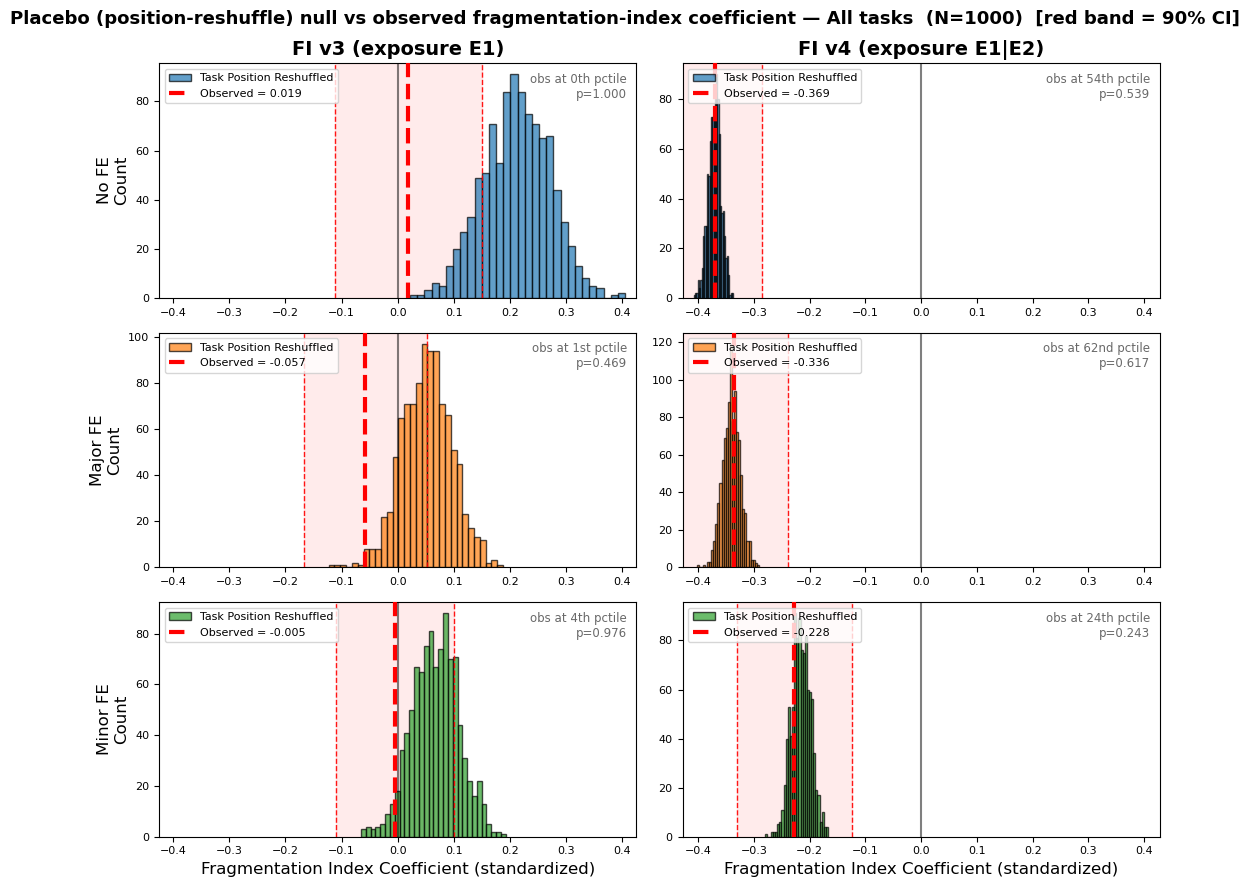

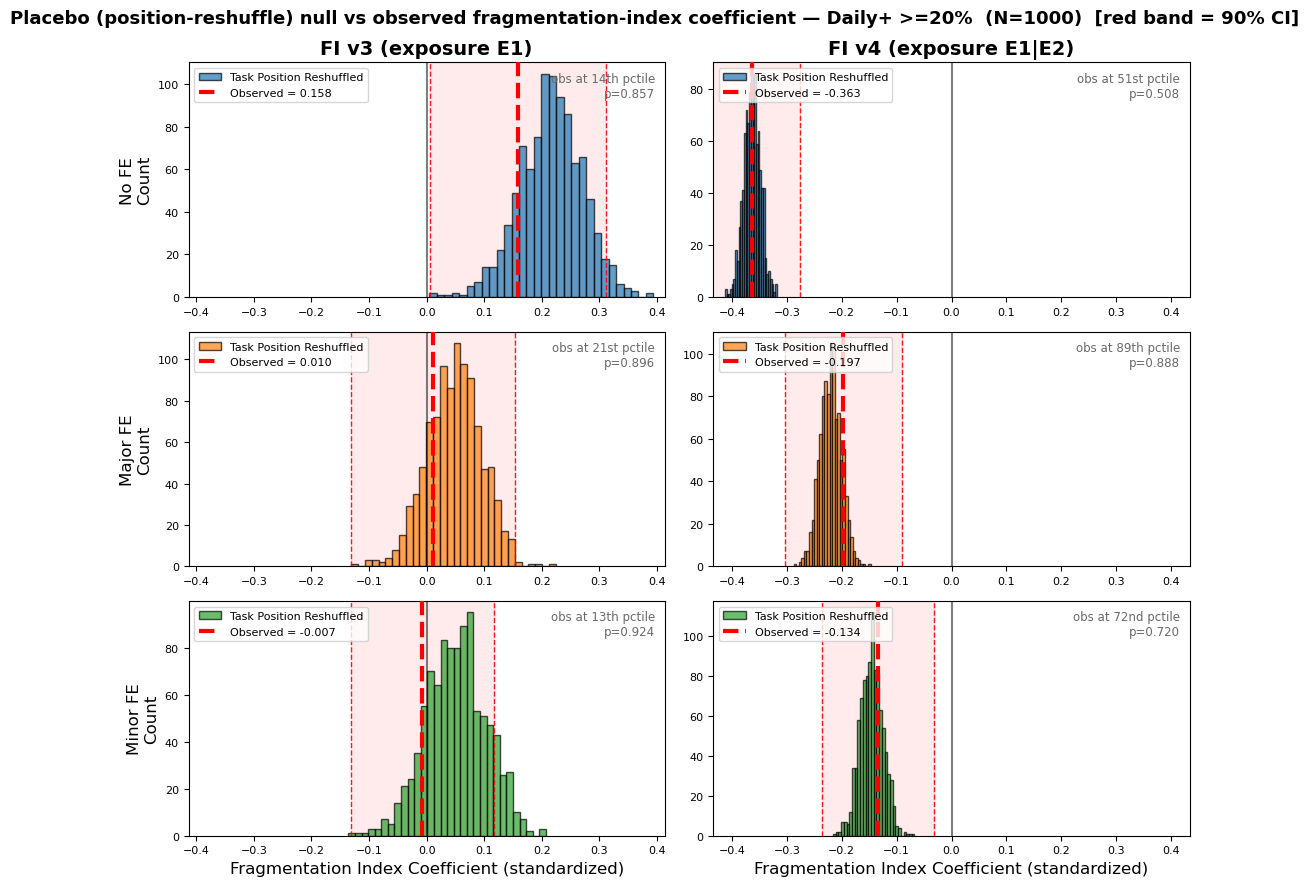

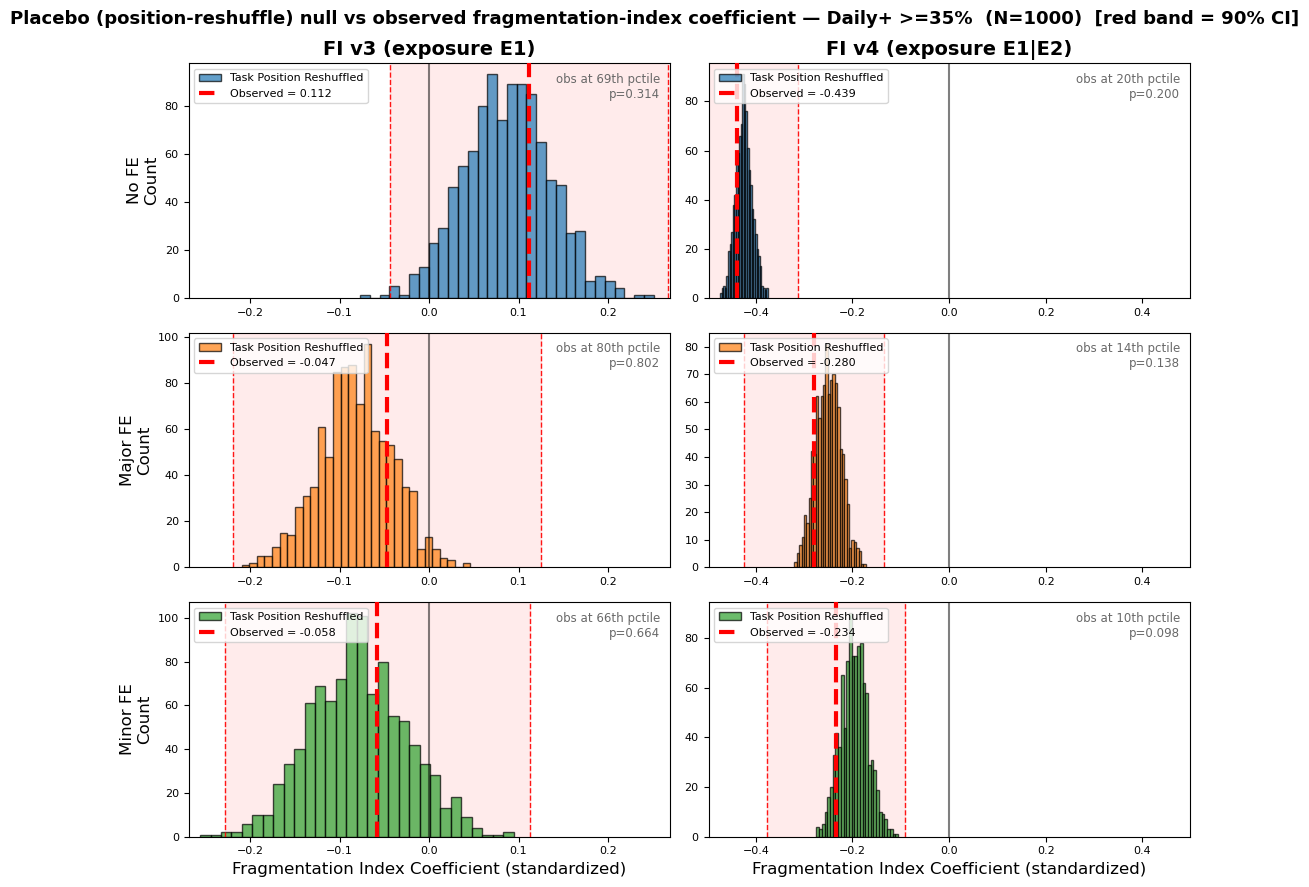

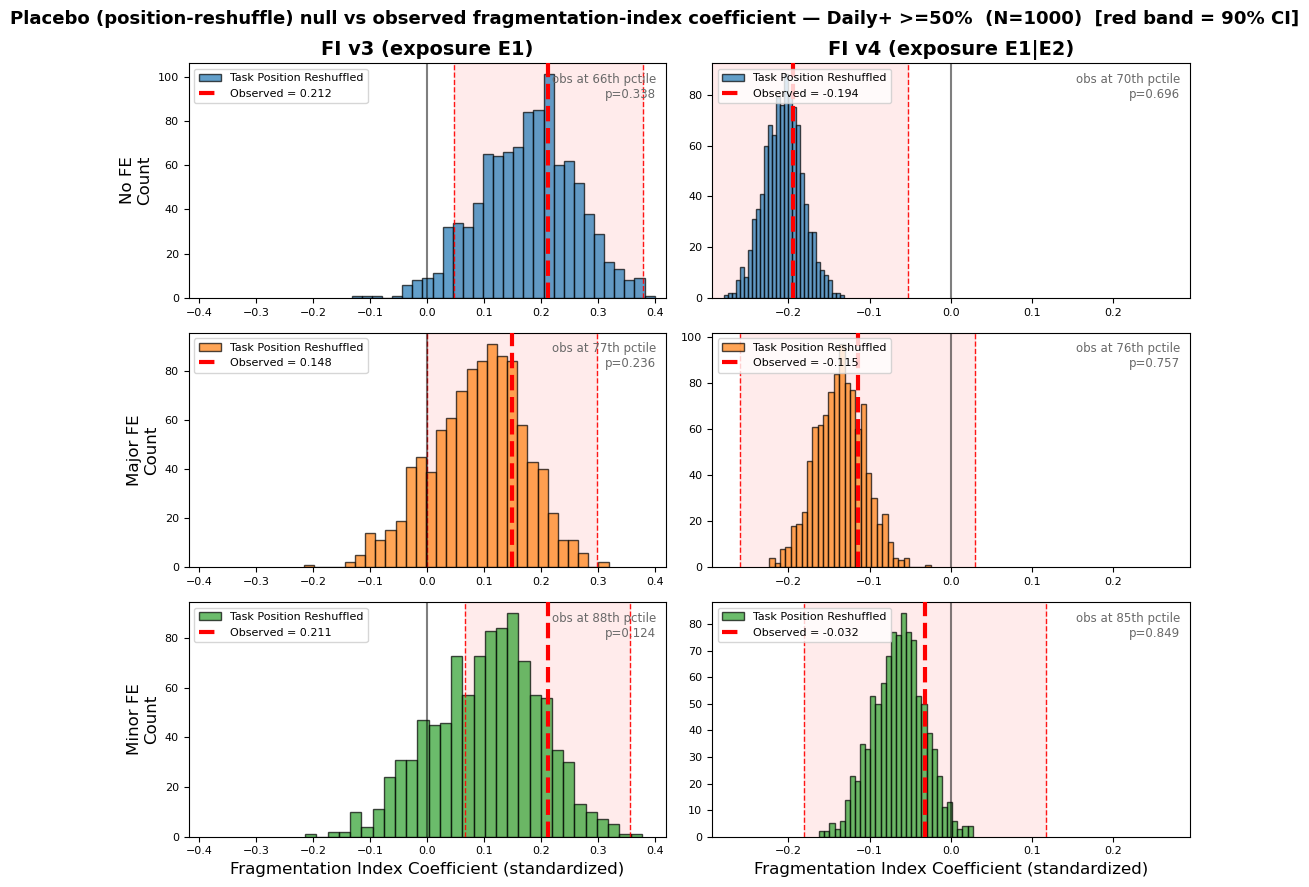

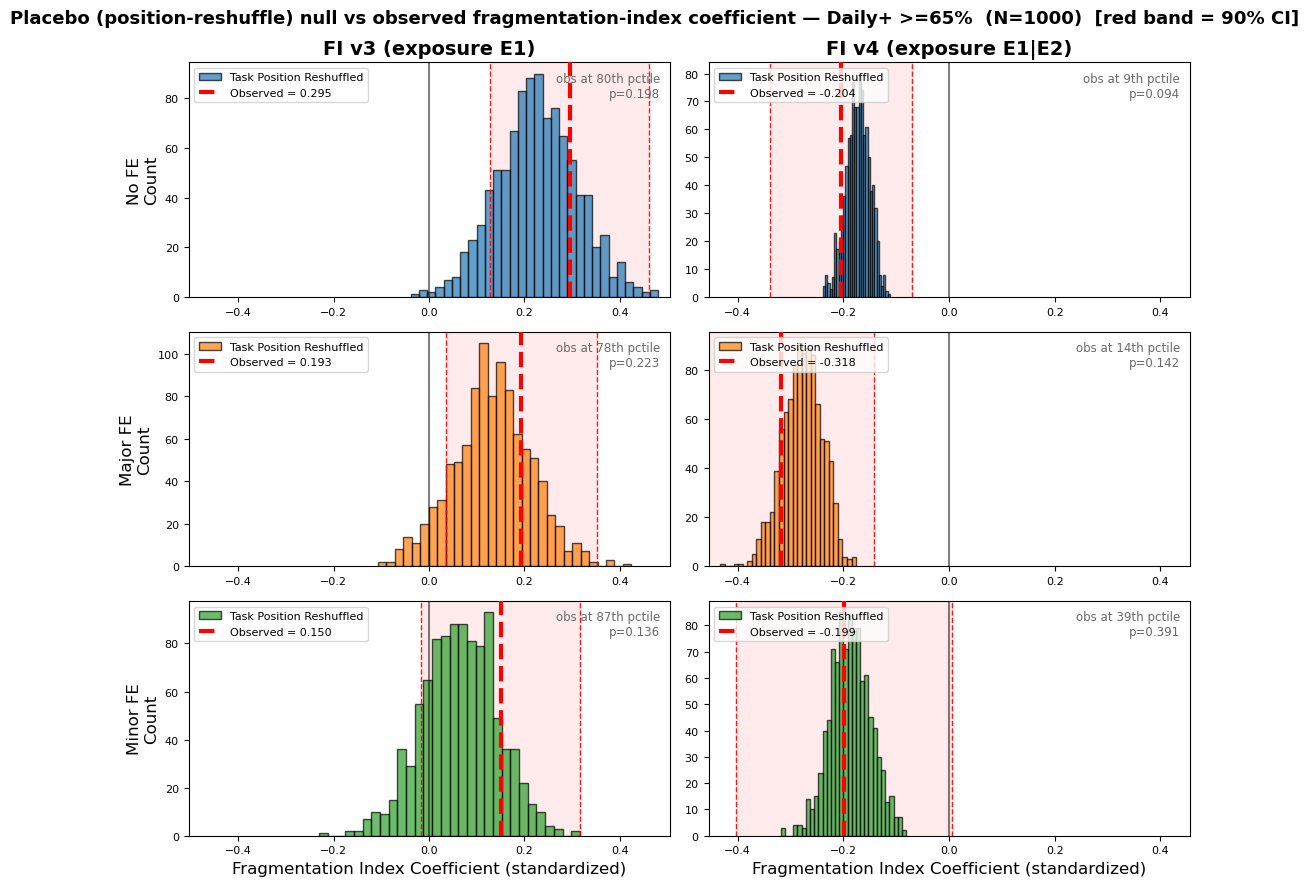

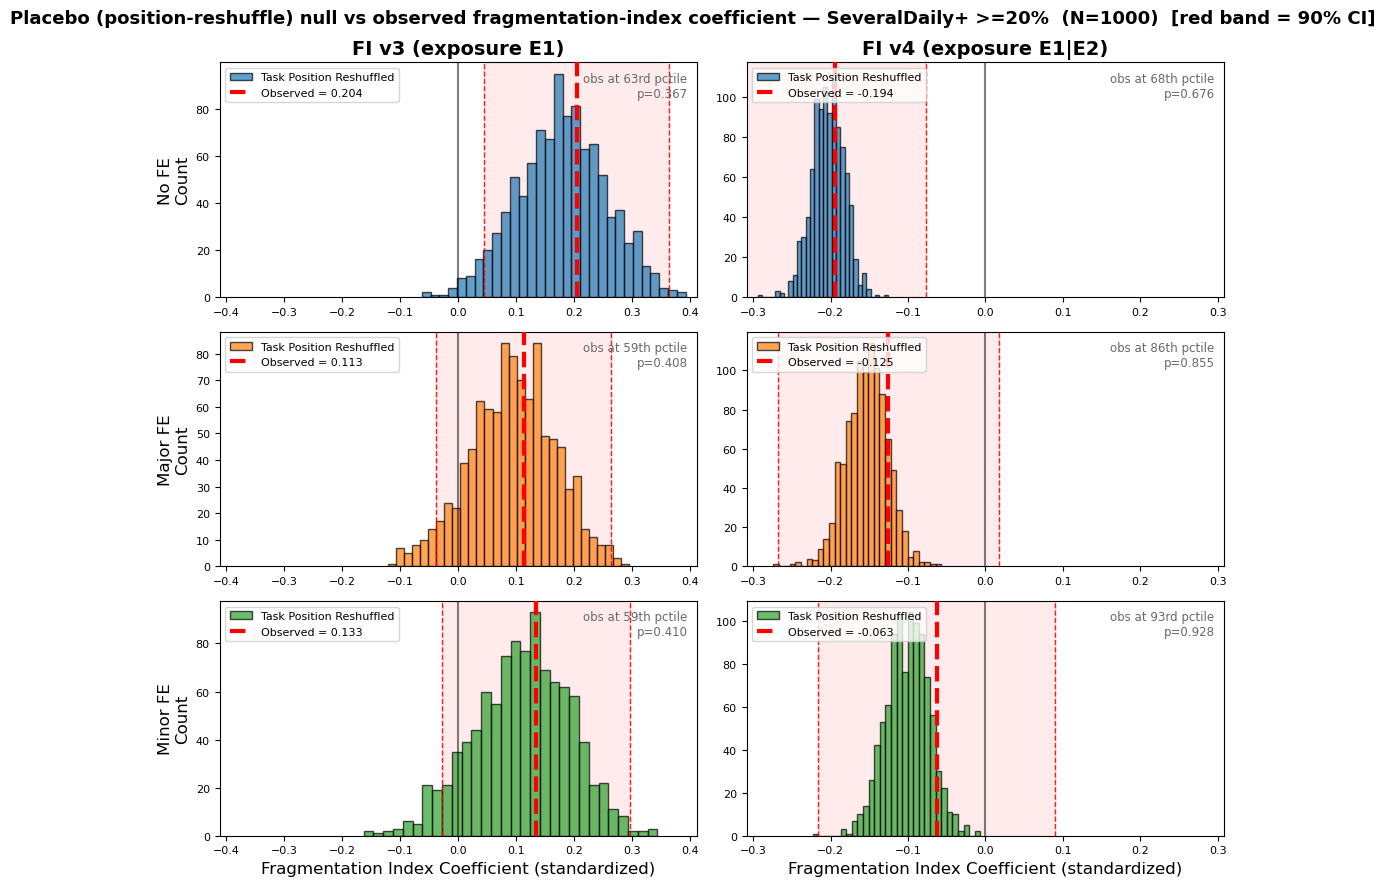

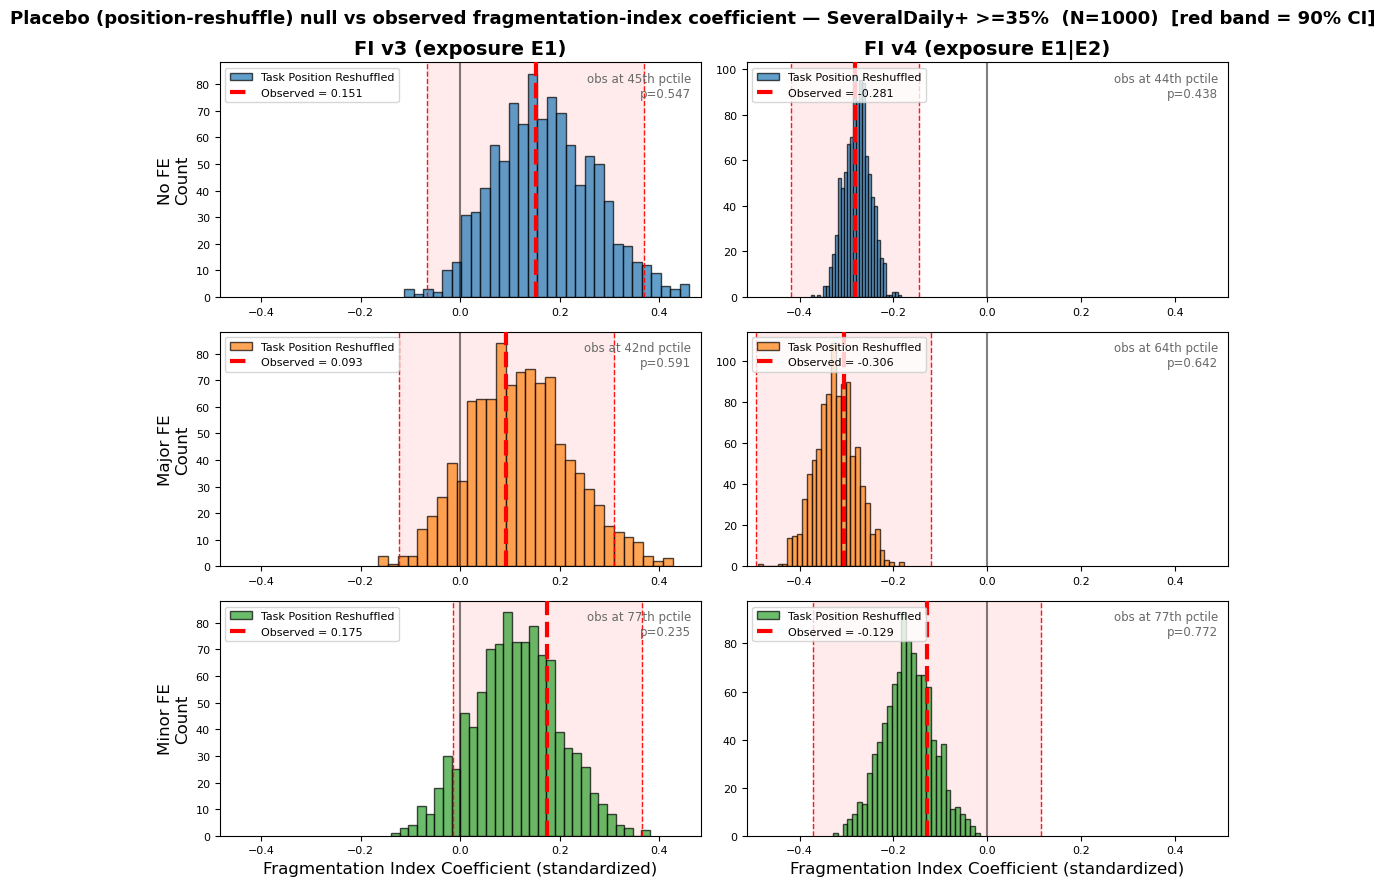

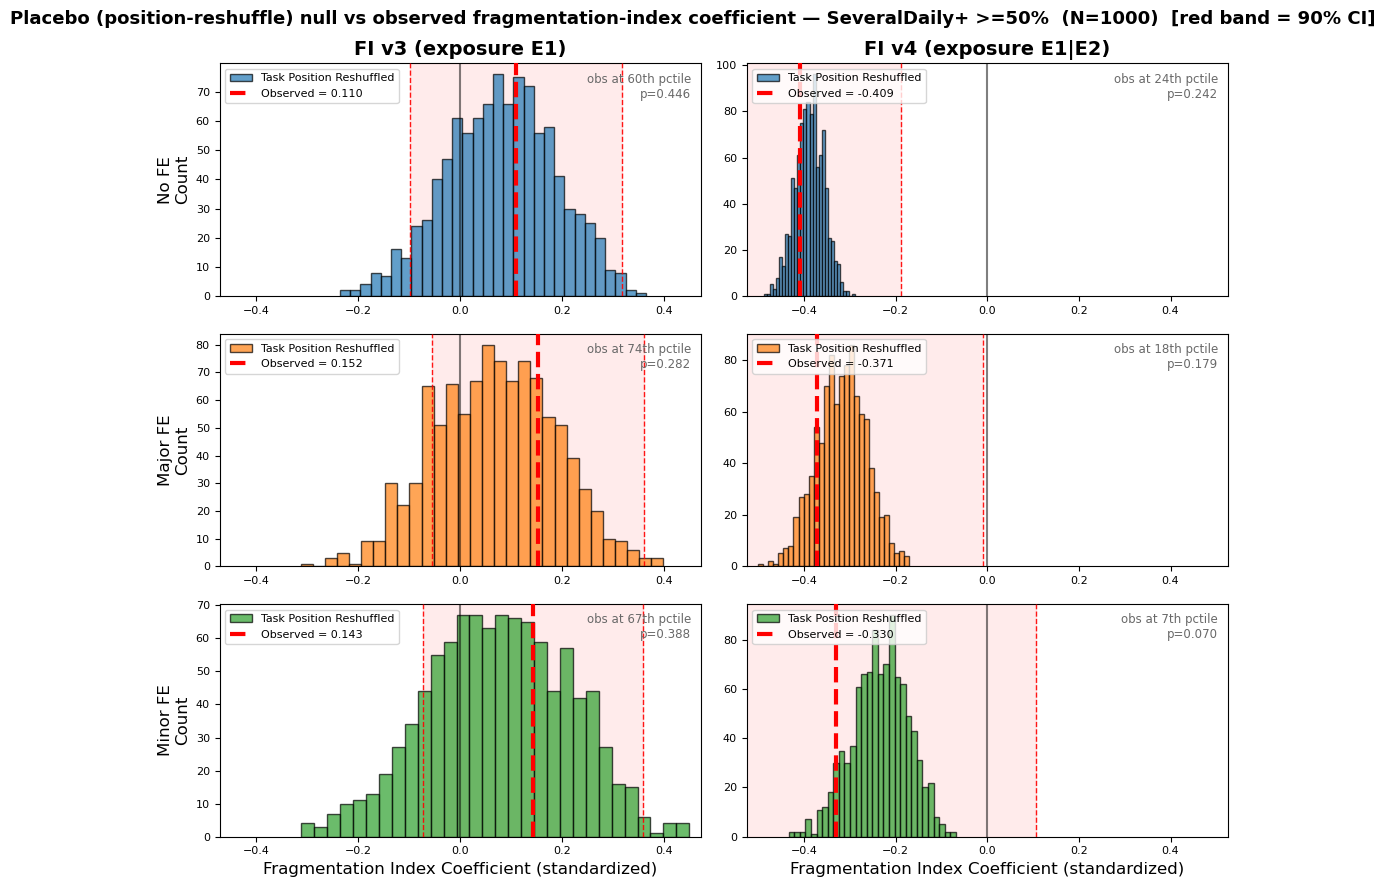

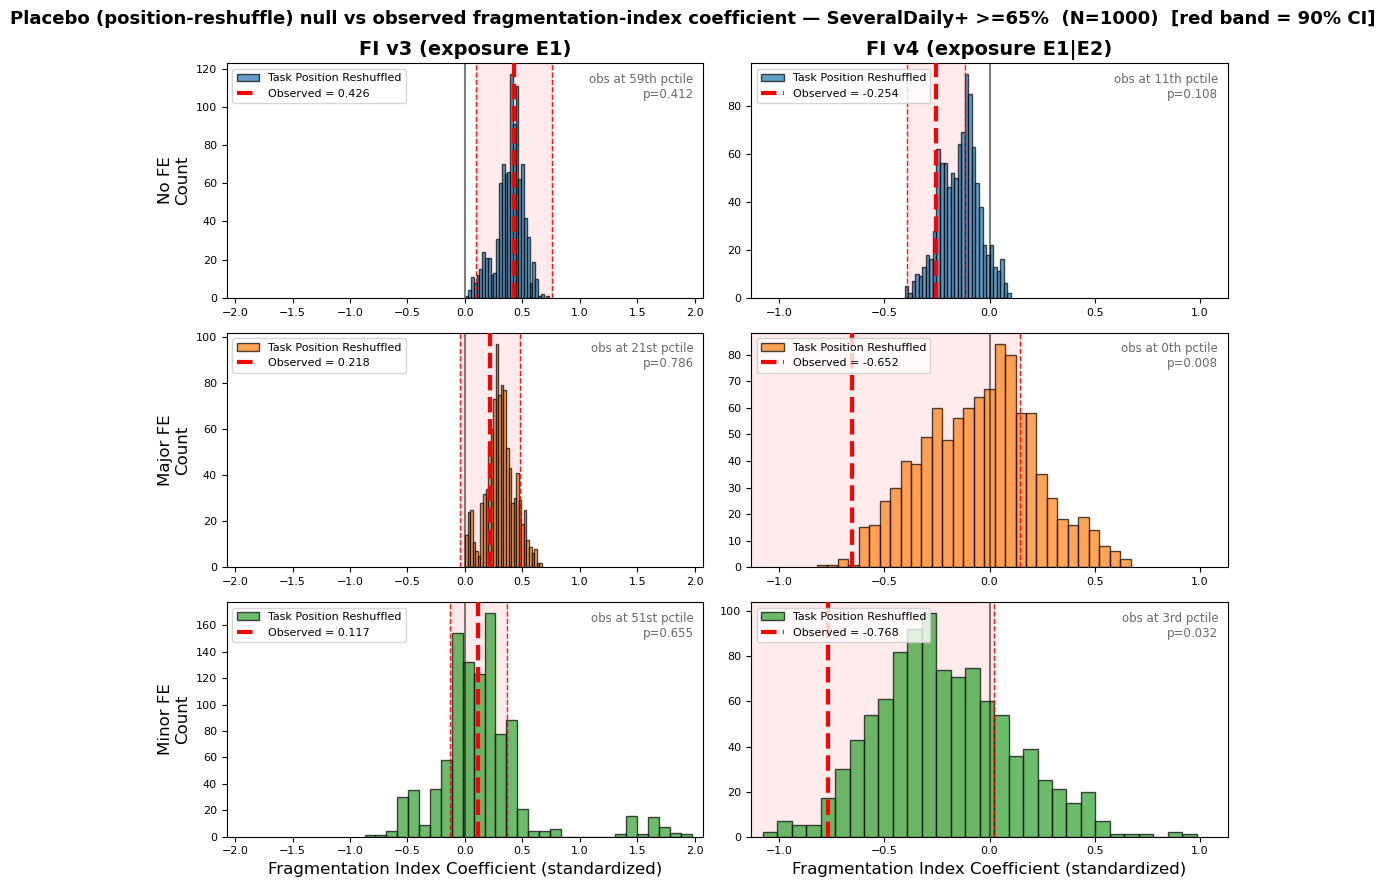

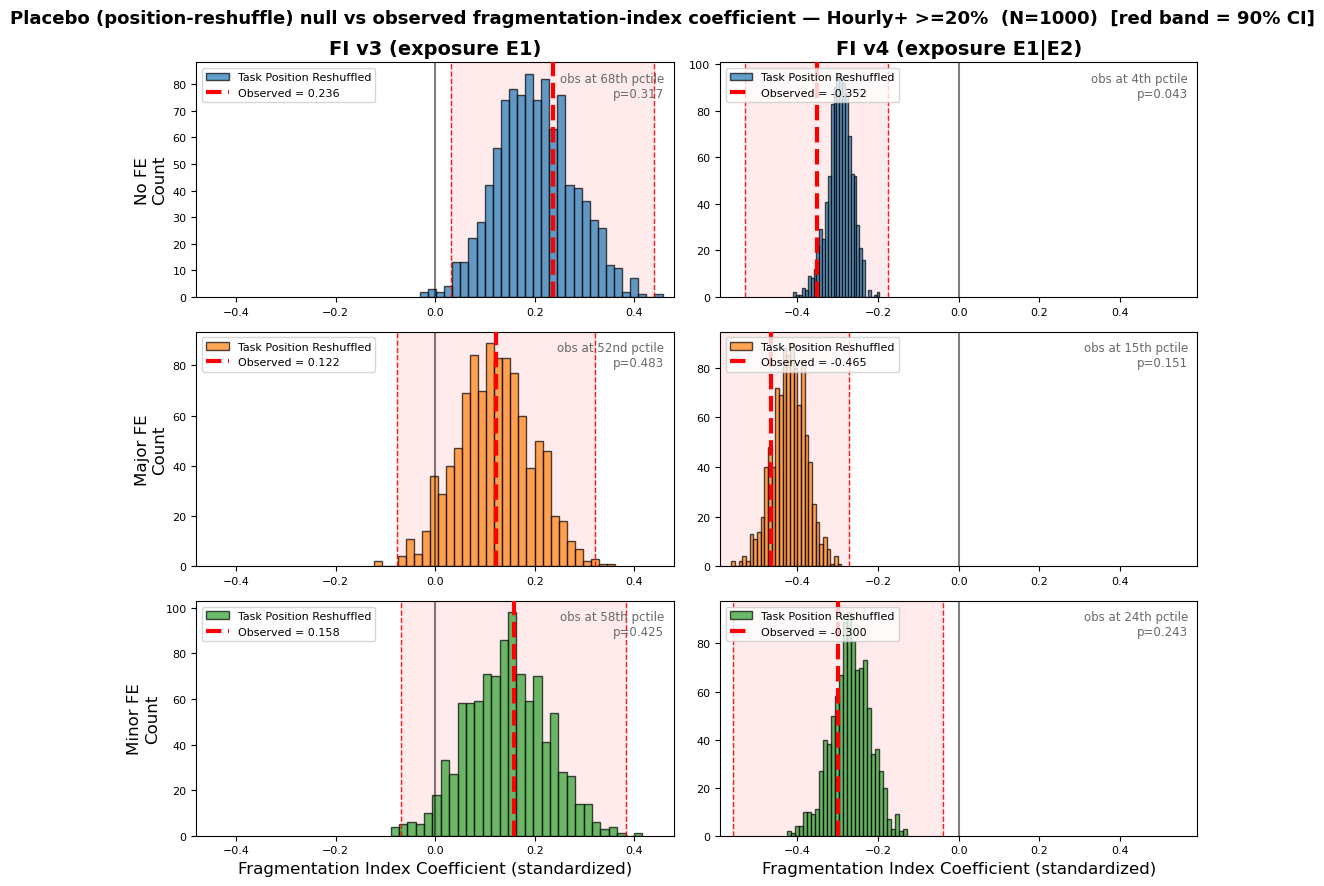

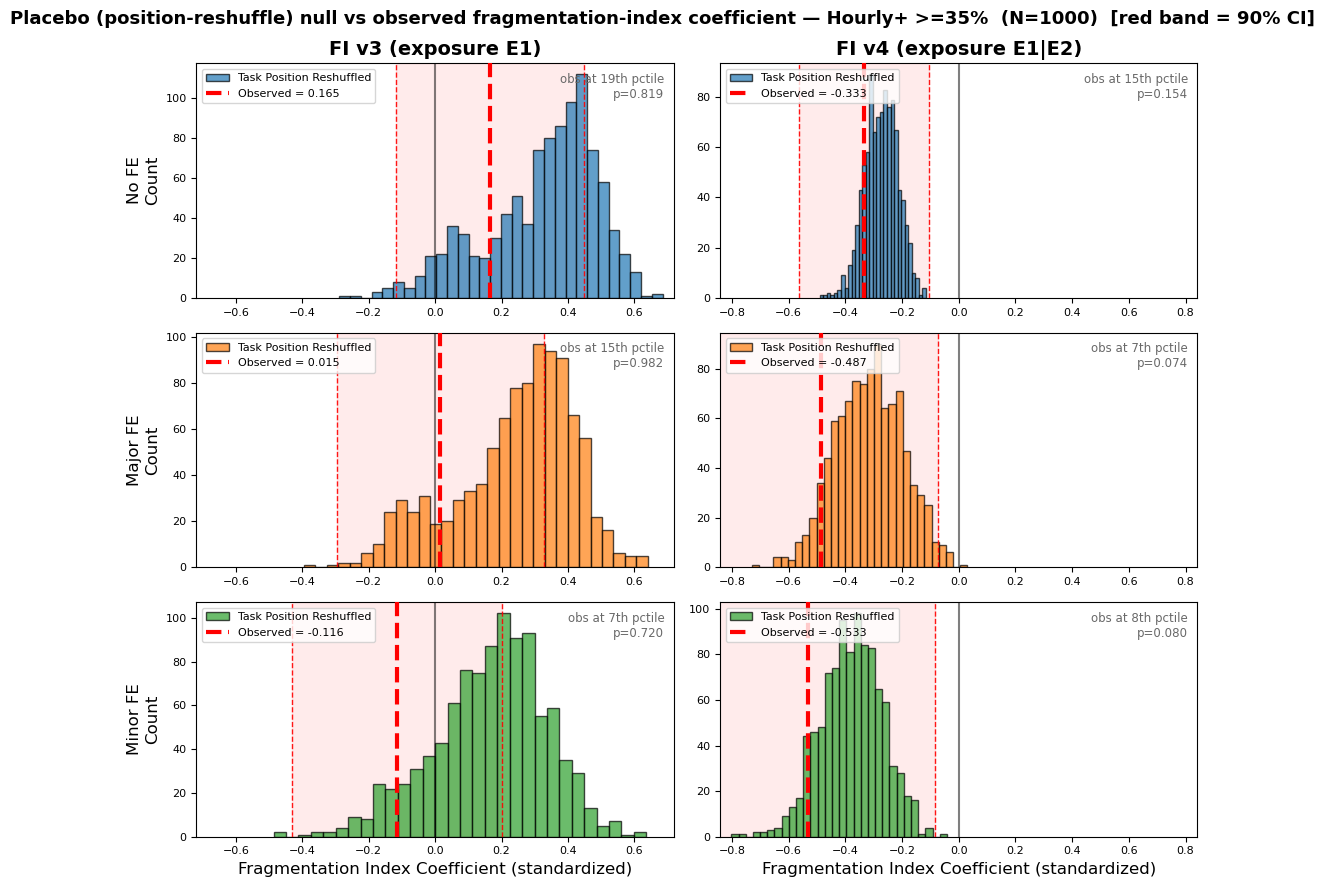

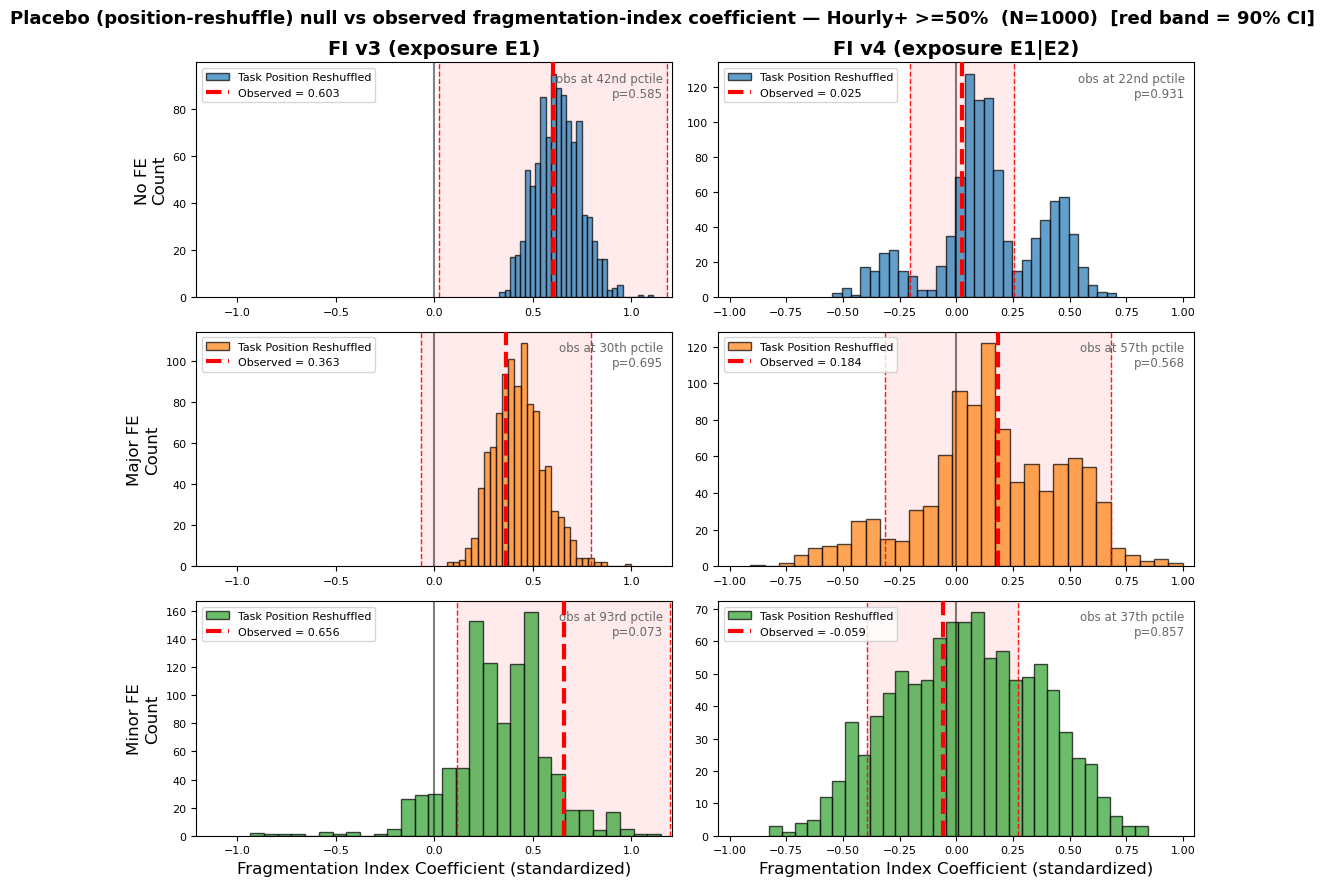

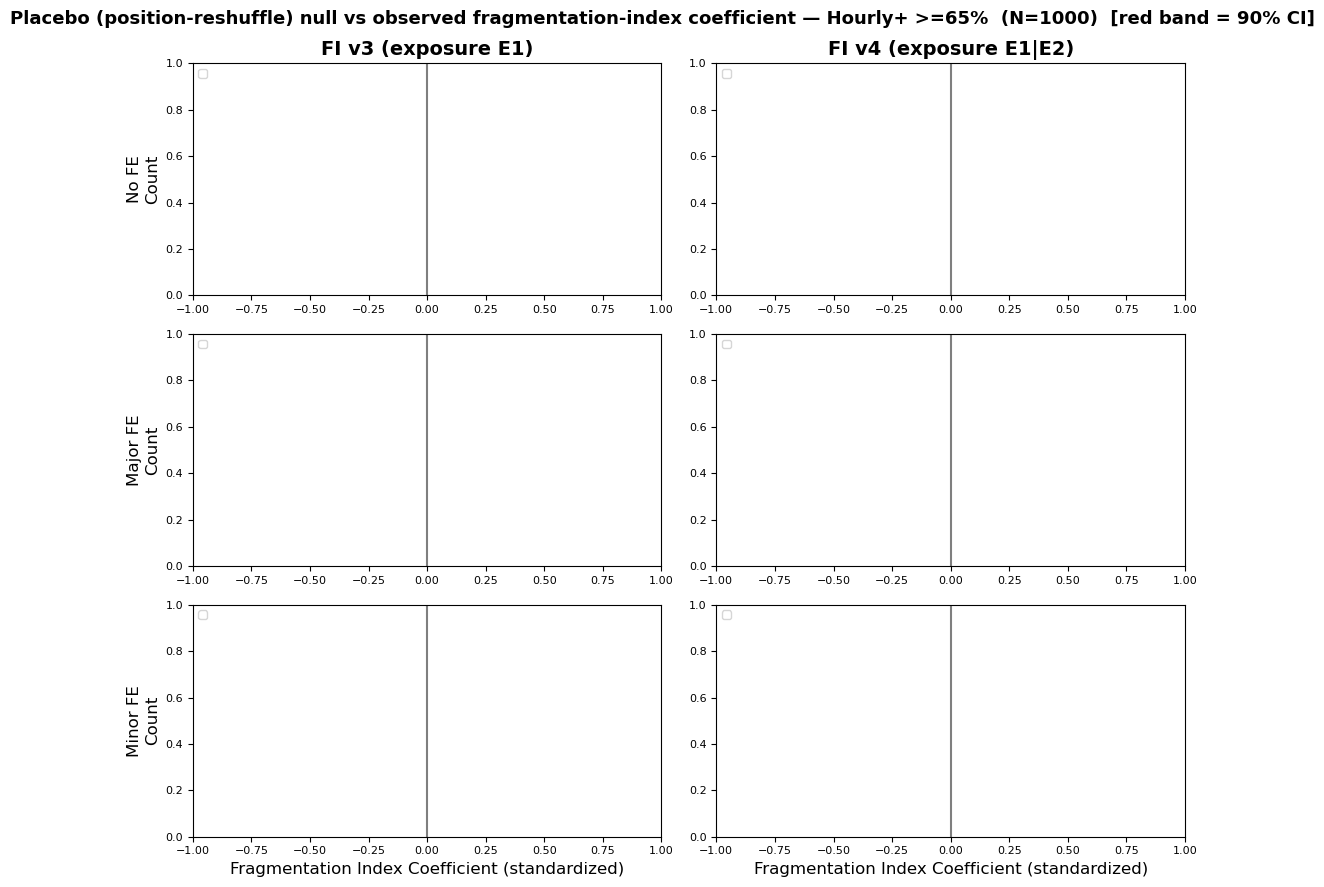

Saved 13 fragmentation placebo figures to ../writeup/plots/fragmentationIndex_weeklyTasks/placebo


In [8]:
SPEC_COLORS = [plt.cm.tab10(i % 10) for i in range(len(FE_SPECS))]
N_DRAWS = int(null_df['draw'].nunique())

def rand_p(vals, obs):
    v = np.asarray([x for x in vals if not np.isnan(x)], float)
    if not len(v) or np.isnan(obs): return np.nan
    return (1 + np.sum(np.abs(v) >= abs(obs))) / (1 + len(v))

def pctile(vals, obs):
    '''Percentile of the placebo (null) distribution that the observed value falls into.'''
    v = np.asarray([x for x in vals if not np.isnan(x)], float)
    if not len(v) or np.isnan(obs): return np.nan
    return 100.0 * np.mean(v < obs)

def _ord(n):
    n = int(round(n)); suf = {1: 'st', 2: 'nd', 3: 'rd'}.get(n % 10 if n % 100 not in (11, 12, 13) else 0, 'th'); return f"{n}{suf}"

def plot_cut(tag, label):
    sub = null_df[null_df.cut_tag == tag]
    # per-COLUMN x-range: each FI definition gets its own range (shared across the 3 FE rows in that column)
    col_bnd = {}
    for dfn in FI_DEFS:
        vv = [x for x in sub[sub.FI_def == f'v{dfn}']['coef'].tolist() if not np.isnan(x)] + \
             [observed[tag][(dfn, f)][0] for f in FE_SPECS if not np.isnan(observed[tag][(dfn, f)][0])]
        col_bnd[dfn] = max(abs(min(vv)), abs(max(vv))) * 1.05 if vv else 1.0
    fig, axes = plt.subplots(len(FE_SPECS), len(FI_DEFS), figsize=(5.5*len(FI_DEFS), 3.0*len(FE_SPECS)), squeeze=False)
    for r, fe in enumerate(FE_SPECS):
        cr = SPEC_COLORS[r]
        for c, dfn in enumerate(FI_DEFS):
            ax = axes[r][c]
            vals = sub[(sub.FI_def == f'v{dfn}') & (sub.FE == fe)]['coef']; vals = vals[~vals.isna()]
            obs, se, _ = observed[tag][(dfn, fe)]
            if len(vals): ax.hist(vals, bins=30, color=cr, alpha=0.7, edgecolor='k', label='Task Position Reshuffled', zorder=2)
            if not np.isnan(obs) and not np.isnan(se):
                b = 1.645 * se; ax.axvspan(obs-b, obs+b, color='red', alpha=0.08, zorder=1)
                ax.axvline(obs-b, color='red', ls='--', lw=1, alpha=0.9, zorder=3); ax.axvline(obs+b, color='red', ls='--', lw=1, alpha=0.9, zorder=3)
            if not np.isnan(obs): ax.axvline(obs, color='red', ls='--', lw=3, label=f'Observed = {obs:.3f}', zorder=4)
            ax.axvline(0.0, color='black', ls='-', lw=1.5, alpha=0.5, zorder=4)
            ax.set_xlim(-col_bnd[dfn], col_bnd[dfn]); ax.tick_params(labelsize=8); ax.legend(fontsize=8, loc='upper left')
            p = rand_p(vals.tolist(), obs); pc = pctile(vals.tolist(), obs)
            ann = ([f"obs at {_ord(pc)} pctile"] if not np.isnan(pc) else []) + ([f"p={p:.3f}"] if not np.isnan(p) else [])
            if ann: ax.text(0.98, 0.96, "\n".join(ann), transform=ax.transAxes, ha='right', va='top', fontsize=8.5, color='dimgray')
            if r == 0: ax.set_title(FI_DEF_TITLE[dfn], fontsize=14, fontweight='bold')
            if r == len(FE_SPECS)-1: ax.set_xlabel('Fragmentation Index Coefficient (standardized)', fontsize=12)
            if c == 0: ax.set_ylabel(f'{FE_LABEL[fe]}\nCount', fontsize=12)
    fig.suptitle(f"Placebo (position-reshuffle) null vs observed fragmentation-index coefficient — {label}  (N={N_DRAWS})  [red band = 90% CI]",
                 fontweight='bold', fontsize=13)
    fig.tight_layout(); fig.savefig(f"{output_plot_path}/frag_placebo_{tag}.png", dpi=130, bbox_inches='tight'); plt.show(); plt.close(fig)

for label, tag, cols, thr in PLACEBO_CUTS:
    plot_cut(tag, label)
print(f"Saved {len(PLACEBO_CUTS)} fragmentation placebo figures to {output_plot_path}")

## Notes

- Timing trial at `N_RESHUFFLES = 10`; scale up by editing `N_RESHUFFLES`.
- Same shuffle mechanic/seeds as the main analysis (`random_state = 42 + i`); one shuffle per draw shared
  across cuts; FI recomputed on the reshuffled order while the AI-execution share and exposure (order-
  independent) stay fixed.
- Outputs: `frag_placebo_null_draws.csv`, `frag_placebo_observed.csv`, figures under
  `writeup/plots/fragmentationIndex_weeklyTasks/placebo/`.